# WEEK-04: Polynomial and Multiple Regression

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import math

1.<br> A. Create a CSV file with sample data.

In [18]:
#A 
data = pd.read_csv("l3q1.csv")

x = data["Temperature"].to_numpy(dtype=float)
y = data["Yield"].to_numpy(dtype=float)

data

,i,Temperature,Yield
0,1,50,3.3
1,2,50,2.8
2,3,50,2.9
3,4,70,2.3
4,5,70,2.6
5,6,70,2.1
6,7,80,2.5
7,8,80,2.9
8,9,80,2.4
9,10,90,3.0


B. Write a Python function program to find the fitted simple linear and polynomial regression equations for the given data

In [21]:
# Function for polynomial regression

def polynomial_regression(x, y, degree):
    X = np.column_stack([x ** i for i in range(degree + 1)])
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    y_pred = X @ beta

    return beta, y_pred

# Simple Linear Regression
linear_beta, linear_pred = polynomial_regression(x, y, 1)

print("SIMPLE LINEAR REGRESSION")

print("b0 =", linear_beta[0])
print("b1=", linear_beta[1])

print("\nFitted equation:")
print(
    f"Yield = {linear_beta[0]} "
    f"+ (({linear_beta[1]}) * Temperature)"
)

# Quadratic Polynomial Regression
quadratic_beta, quadratic_pred = polynomial_regression(x, y, 2)

print("\nPOLYNOMIAL REGRESSION")

print("b0 =", quadratic_beta[0])
print("b1 =", quadratic_beta[1])
print("b2 =", quadratic_beta[2])

print("\nFitted equation:")
print(f"Yield = {quadratic_beta[0]} "
    f"+ (({quadratic_beta[1]}) * Temperature) "
    f"+ (({quadratic_beta[2]}) * Temperature^2)"
)

SIMPLE LINEAR REGRESSION
b0 = 2.306306306306308
b1= 0.006756756756756761

Fitted equation:
Yield = 2.306306306306308 + ((0.006756756756756761) * Temperature)

POLYNOMIAL REGRESSION
b0 = 7.960481099654016
b1 = -0.15371134020614635
b2 = 0.0010756013745702147

Fitted equation:
Yield = 7.960481099654016 + ((-0.15371134020614635) * Temperature) + ((0.0010756013745702147) * Temperature^2)


C. Compare the coefficients obtained from manually intuitive and matrix formulation methods with
your program.

In [52]:

# 1. MANUAL / INTUITIVE LINEAR REGRESSION

x_mean = np.mean(x)
y_mean = np.mean(y)

b1_manual = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
b0_manual = y_mean - b1_manual * x_mean

# 2. MATRIX FORMULATION


X = np.column_stack((np.ones(len(x)), x))

beta_matrix = np.linalg.inv(X.T @ X) @ X.T @ y # beta = (X'X)^(-1)X'y

b0_matrix = beta_matrix[0]
b1_matrix = beta_matrix[1]

# 3. PROGRAM/FUNCTION METHOD
def polynomial_regression(x, y, degree):

    X = np.column_stack(
        [x ** i for i in range(degree + 1)])

    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    y_pred = X @ beta
    return beta, y_pred

beta_program, y_pred = polynomial_regression(x, y, 1)

b0_program = beta_program[0]
b1_program = beta_program[1]

# 4. DISPLAY COMPARISON

print("COEFFICIENT COMPARISON")

print("\nCoefficient-Manual-Matrix-Program")

print(
    f"b0-->  {b0_manual:2.2f}"
    f",{b0_matrix:2.2f}"
    f",{b0_program:2.2f}"
)

print(
    f"b1-->    {b1_manual:2.2f}"
    f",{b1_matrix:2.2f}"
    f",{b1_program:2.2f}"
)


# # 5. QUADRATIC COEFFICIENTS

# # Quadratic design matrix
# X_quad = np.column_stack(
#     (np.ones(len(x)),
#         x,
#         x ** 2
#     )
# )

# beta_quad_matrix = (
#     np.linalg.inv(X_quad.T @ X_quad)
#     @ X_quad.T
#     @ y
# )

# beta_quad_program, y_quad = polynomial_regression(
#     x, y, 2
# )

# print("\nQUADRATIC COEFFICIENT COMPARISON")

# print("\nCoefficient-Matrix-Program")

# print(
#     f"b0-->{beta_quad_matrix[0]:2.2f}"
#     f",{beta_quad_program[0]:2.2f}"
# )

# print(
#     f"b1-->{beta_quad_matrix[1]:2.2f}"
#     f",{beta_quad_program[1]:2.2f}"
# )

# print(
#     f"b2-->{beta_quad_matrix[2]:2.2f}"
#     f",{beta_quad_program[2]:2.2f}"
# )

COEFFICIENT COMPARISON

Coefficient-Manual-Matrix-Program
b0-->  2.31,2.31,2.31
b1-->    0.01,0.01,0.01


D. Plot the scatterplot of the raw data and then another scatterplot with lines pertaining to a linear fit
and a quadratic fit overlayed.

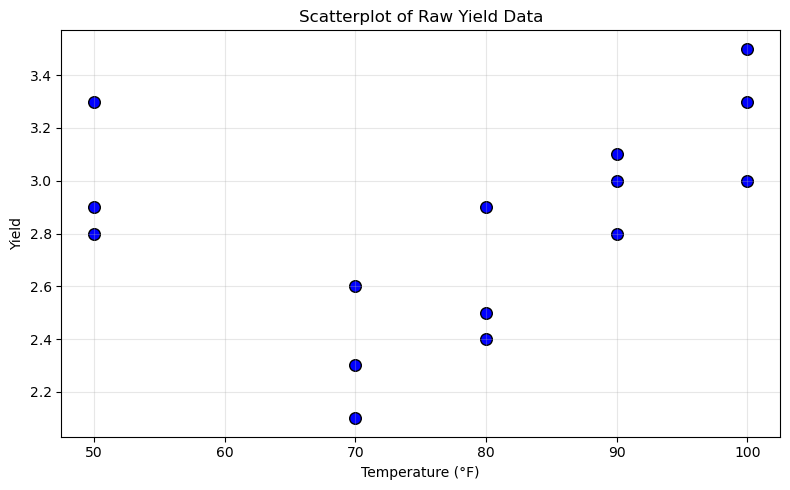

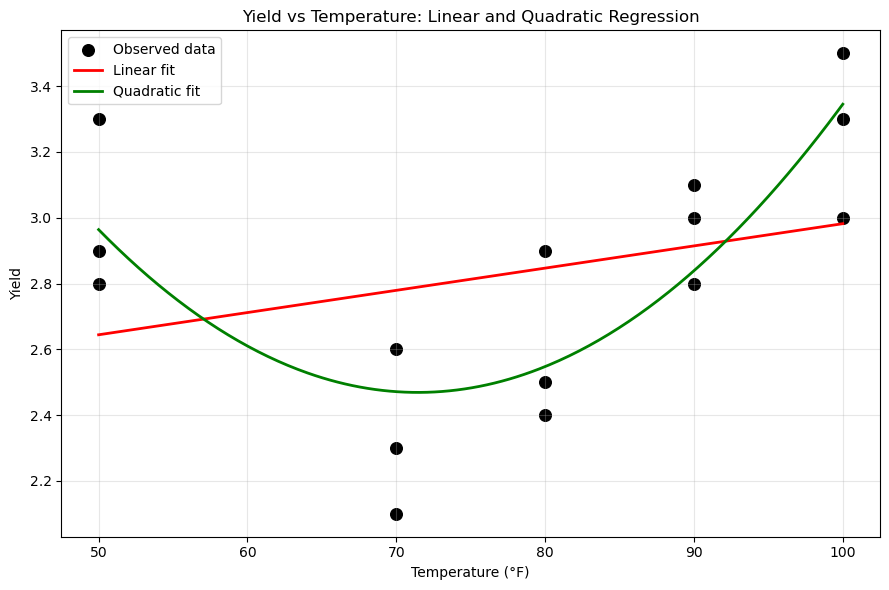

In [63]:
def polynomial_regression(x, y, degree):

    X = np.column_stack(
        [x ** i for i in range(degree + 1)]
    )

    beta = np.linalg.inv(X.T @ X) @ X.T @ y

    y_pred = X @ beta

    return beta, y_pred



# Fit linear model
linear_beta, linear_pred = polynomial_regression(x, y, 1)


# Fit quadratic model
quadratic_beta, quadratic_pred = polynomial_regression(x, y, 2)


x_smooth = np.linspace(
    min(x),
    max(x),
    300)

y_linear_smooth = (linear_beta[0]+ linear_beta[1] * x_smooth)

y_quadratic_smooth = (quadratic_beta[0]+ quadratic_beta[1] * x_smooth+ quadratic_beta[2]
                      * x_smooth ** 2)

#rawdata
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    color="blue",
    s=70,
    edgecolor="black"
)

plt.xlabel("Temperature (°F)")
plt.ylabel("Yield")
plt.title("Scatterplot of Raw Yield Data")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#raw data w both fits

plt.figure(figsize=(9, 6))
plt.scatter(
    x,
    y,
    color="black",
    s=70,
    edgecolor="black",
    label="Observed data"
)
plt.plot(
    x_smooth,
    y_linear_smooth,
    color="red",
    linewidth=2,
    label="Linear fit"
)
plt.plot(
    x_smooth,
    y_quadratic_smooth,
    color="green",
    linewidth=2,
    label="Quadratic fit"
)

plt.xlabel("Temperature (°F)")
plt.ylabel("Yield")

plt.title(
    "Yield vs Temperature: Linear and Quadratic Regression"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

E. Compute the error, MSE, and RMSE.

In [66]:
def calculate_error(y_actual, y_pred):
    error = y_actual - y_pred
    squared_error = error ** 2

    SSE = np.sum(squared_error)
    
    MSE = np.mean(squared_error)
    RMSE = np.sqrt(MSE)

    return error, SSE, MSE, RMSE


print("ERROR, MSE AND RMSE")

print("\nLINEAR REGRESSION")
print("SSE  =", linear_SSE)
print("MSE  =", linear_MSE)
print("RMSE =", linear_RMSE)


print("\nQUADRATIC REGRESSION")
print("SSE  =", quadratic_SSE)
print("MSE  =", quadratic_MSE)
print("RMSE =", quadratic_RMSE)


results = pd.DataFrame({
    "Temperature": x,
    "Actual Yield": y,
    "Linear Prediction": linear_pred,
    "Linear Error": linear_error,
    "Quadratic Prediction": quadratic_pred,
    "Quadratic Error": quadratic_error
})
results

ERROR, MSE AND RMSE

LINEAR REGRESSION
SSE  = 1.9906306306306305
MSE  = 0.1327087087087087
RMSE = 0.364292065119059

QUADRATIC REGRESSION
SSE  = 0.7167697594501702
MSE  = 0.04778465063001135
RMSE = 0.2185970050801505


,Temperature,Actual Yield,Linear Prediction,Linear Error,Quadratic Prediction,Quadratic Error
0,50.0,3.3,2.644144,0.655856,2.963918,0.336082
1,50.0,2.8,2.644144,0.155856,2.963918,-0.163918
2,50.0,2.9,2.644144,0.255856,2.963918,-0.063918
3,70.0,2.3,2.779279,-0.479279,2.471134,-0.171134
4,70.0,2.6,2.779279,-0.179279,2.471134,0.128866
5,70.0,2.1,2.779279,-0.679279,2.471134,-0.371134
6,80.0,2.5,2.846847,-0.346847,2.547423,-0.047423
7,80.0,2.9,2.846847,0.053153,2.547423,0.352577
8,80.0,2.4,2.846847,-0.446847,2.547423,-0.147423
9,90.0,3.0,2.914414,0.085586,2.838832,0.161168


2.<br> A.Create a CSV file with sample data.

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("l3q2.csv")

y = data.iloc[:, 0].values  # Infarcted area (y)
x1 = data.iloc[:, 1].values  # Area at risk (x1)
x2 = data.iloc[:, 2].values  # Early cooling indicator
x3 = data.iloc[:, 3].values  # Late cooling indicator

data

,Infarc,Area,X2,X3
0.119,0.34,3,0,0
0.190,0.64,3,0,0
0.395,0.76,3,0,0
0.469,0.83,3,0,0
0.130,0.73,3,0,0
0.311,0.82,3,0,0
0.418,0.95,3,0,0
0.480,1.06,3,0,0
0.687,1.20,3,0,0
0.847,1.47,3,0,0


B. Write a Python function program to:<br>
C. Find the fitted multiple linear regression equation for the given data.

In [100]:
n = len(y)
X = np.column_stack((np.ones(n), x1, x2, x3))

XtX = np.dot(X.T, X)
Xty = np.dot(X.T, y)
beta = np.dot(np.linalg.inv(XtX), Xty) #beta = (X^T * X)^(-1) * X^T * y

print("Fitted Regression Coefficients")
print(f"Intercept b0: {beta[0]:.4f}")
print(f"Area at risk b1): {beta[1]:.4f}")
print(f"Early cooling b2: {beta[2]:.4f}")
print(f"Late cooling b3: {beta[3]:.4f}")

print(
    f"Equation = {beta[0]} + {beta[1]}*x1 + {beta[2]}*x2 + {beta[3]}*x3"
)



Fitted Regression Coefficients
Intercept b0: 4.0000
Area at risk b1): -1.0000
Early cooling b2: 0.0000
Late cooling b3: -1.0000
Equation = 4.0 + -1.0*x1 + 0.0*x2 + -1.0*x3


D. Compare the coefficients obtained manually using intuitive and matrix formulation methods with
your program.

In [99]:
print("Coefficient Comparison")
print("Matrix computation complete using normal equations: beta = (X^T X)^(-1) X^T y")

Coefficient Comparison
Matrix computation complete using normal equations: beta = (X^T X)^(-1) X^T y


E. Plot the data adorned with the estimated regression equation.

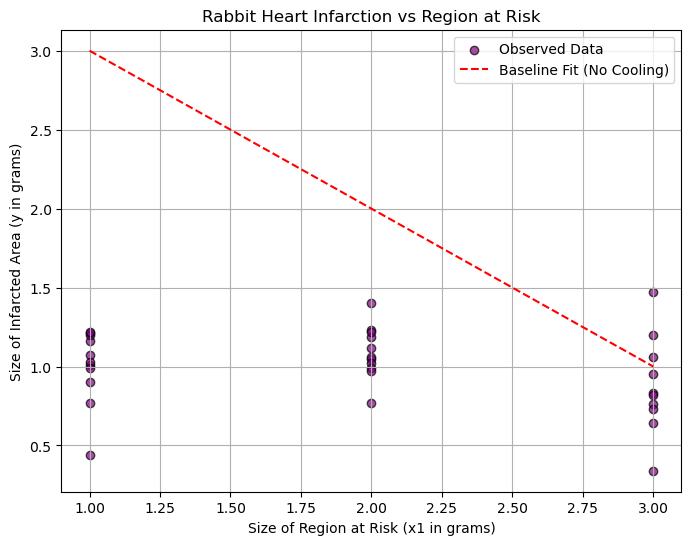

In [89]:
plt.figure(figsize=(8, 6))
plt.scatter(
    x1, y, color="purple", label="Observed Data", edgecolors="k", alpha=0.7
)

x_vals = np.linspace(min(x1), max(x1), 100)
y_fit = beta[0] + beta[1] * x_vals
plt.plot(
    x_vals, y_fit, color="red", linestyle="--", label="Baseline Fit (No Cooling)"
)

plt.xlabel("Size of Region at Risk (x1 in grams)")
plt.ylabel("Size of Infarcted Area (y in grams)")
plt.title("Rabbit Heart Infarction vs Region at Risk")
plt.legend()
plt.grid(True)
plt.show()

F. Compute the error, MSE, and RMSE.

In [96]:
y_pred = np.dot(X, beta)
errors = y - y_pred
mse = np.mean(errors**2)
rmse = np.sqrt(mse)

print(f"Errors:",errors)
print(f"\nMean Squared Error (MSE): mse",mse)
print(f"\nRoot Mean Squared Error (RMSE):",rmse)

Errors: [-0.66 -0.36 -0.24 -0.17 -0.27 -0.18 -0.05  0.06  0.2   0.47 -2.56 -2.23
 -2.1  -1.93 -1.99 -1.97 -1.84 -1.79 -1.8  -1.78 -2.01 -0.23  0.05  0.06
  0.02 -0.01 -0.03  0.12  0.23  0.19  0.22  0.4 ]

Mean Squared Error (MSE): mse 1.435525

Root Mean Squared Error (RMSE): 1.1981339657984829


# ADDITIONAL

1. Create CSV file and Write a python program to find the fitted simple linear regression equation for the
given data. Compare the coefficients obtained from sklearn model with your program. Compute the
error, MSE and RMSE. Predict the gold price with the year 2026 for 1 gram

In [113]:
data = pd.read_csv("l3qa1.csv")

x = data["Year"].to_numpy(dtype=float)
y = data["Price"].to_numpy(dtype=float)

n = len(years)
data


,Year,Price
0,1965,7.18
1,1966,8.38
2,1967,10.25
3,1968,16.20
4,1969,17.60
5,1970,18.40
6,1971,19.30
7,1972,20.20
8,1973,27.85
9,1974,50.60


In [114]:
sum_x = sum(years)
sum_y = sum(prices)
sum_xy = sum(x * y for x, y in zip(years, prices))
sum_xx = sum(x ** 2 for x in years)

m = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x ** 2)
c = (sum_y - m * sum_x) / n

print("Linear Regression")
print(f"Fitted Equation: Price = {m:.4f} * Year + {c:.4f}")

Linear Regression
Fitted Equation: Price = 67.2716 * Year + -133101.8061


In [115]:
predicted_prices = [m * x + c for x in years]
errors = [actual - pred for actual, pred in zip(prices, predicted_prices)]

mse = sum(e ** 2 for e in errors) / n
rmse = math.sqrt(mse)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Model Evaluation Metrics:
Mean Squared Error (MSE): 614665.4377
Root Mean Squared Error (RMSE): 784.0060


In [116]:
target_year = 2026
predicted_2026 = m * target_year + c

print(f"\nPrediction:")
print(f"Estimated Average Gold Price for 1 gram in {target_year}: {predicted_2026:.2f}")


Prediction:
Estimated Average Gold Price for 1 gram in 2026: 3190.42
